In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Residual Networks: ResNet, ResNeXt, and DenseNet

As we design ever deeper networks it becomes imperative to understand how adding layers can increase the complexity and expressiveness of the network.
Even more important is the ability to design networks where adding layers
preserves every function the shallower network could represent, while making
additional functions available.
To make some progress we need a bit of mathematics.

In [1]:
from d2l import torch as d2l
import torch
from torch import nn
from torch.nn import functional as F

## Function Classes

Consider $\mathcal{F}$, the class of functions represented by a network
architecture as its weights and biases vary. This definition concerns the
parameterization; which members an optimizer can reach is a separate question.
Let's assume that $f^*$ is the "truth" function that we really would like to find.
If it is in $\mathcal{F}$, we are in good shape but typically we will not be quite so lucky.
Instead, we will try to find some $f^*_{\mathcal{F}}$ which is our best bet within $\mathcal{F}$.
For instance,
given a dataset with features $\mathbf{X}$
and labels $\mathbf{y}$,
we might try finding it by solving the following optimization problem:

$$f^*_{\mathcal{F}} \stackrel{\textrm{def}}{=} \mathop{\mathrm{argmin}}_f L(\mathbf{X}, \mathbf{y}, f) \textrm{ subject to } f \in \mathcal{F}.$$

We know that regularization [@tikhonov1977solutions; @morozov2012methods] may control complexity of $\mathcal{F}$
and achieve consistency, so a larger size of training data
generally leads to better $f^*_{\mathcal{F}}$.
It is only reasonable to assume that if we design a different and more powerful architecture $\mathcal{F}'$ we should arrive at a better outcome. In other words, we would expect that $f^*_{\mathcal{F}'}$ is "better" than $f^*_{\mathcal{F}}$. However, if $\mathcal{F} \not\subseteq \mathcal{F}'$ there is no guarantee that this should even happen. In fact, $f^*_{\mathcal{F}'}$ might well be worse.
As illustrated by the figure,
for non-nested function classes, a larger function class does not always move closer to the "truth" function $f^*$. For instance,
on the left of the figure,
though $\mathcal{F}_3$ is closer to $f^*$ than $\mathcal{F}_1$, $\mathcal{F}_6$ moves away and there is no guarantee that further increasing the complexity can reduce the distance from $f^*$.
With nested function classes
where $\mathcal{F}_1 \subseteq \cdots \subseteq \mathcal{F}_6$
on the right of the figure,
we can avoid the aforementioned issue from the non-nested function classes.


![For non-nested function classes, a larger (indicated by area) function class does not guarantee we will get closer to the "truth" function ($\mathit{f}^*$). This does not happen in nested function classes.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/functionclasses.svg)

Thus, if larger function classes contain the smaller ones, increasing capacity
cannot reduce expressive power. The containment may be equality, so the
increase need not be strict.
For deep neural networks,
if a newly added block can represent the identity
$f(\mathbf{x}) = \mathbf{x}$, the deeper model contains the shallower one as a
special case. This protects representation capacity; it does not guarantee
that optimization will find the best member of the larger class.

This is the question that @He.Zhang.Ren.ea.2016 considered when working on very deep computer vision models.
At the heart of their proposed *residual network* (*ResNet*) is the idea that every additional layer should
more easily
contain the identity function as one of its elements.
These considerations led to a simple solution, a *residual block*.
With it, ResNet won the ImageNet Large Scale Visual Recognition Challenge in 2015. The design influenced how to
build deep neural networks. For instance, residual blocks have been added to recurrent networks [@prakash2016neural; @kim2017residual]. Likewise, Transformers [@Vaswani.Shazeer.Parmar.ea.2017] use them to stack many layers of networks efficiently. It is also used in graph neural networks [@Kipf.Welling.2016] and, as a basic concept, it has been used extensively in computer vision [@Redmon.Farhadi.2018; @Ren.He.Girshick.ea.2015]. 
Highway networks [@srivastava2015highway] predate ResNet and share some
of its motivation, using learned gates rather than a direct identity shortcut.


## Residual Blocks

Let's focus on a local part of a neural network, as depicted in the figure. Denote the input by $\mathbf{x}$.
We assume that $f(\mathbf{x})$, the desired underlying mapping we want to obtain by learning, is to be used as input to the activation function on the top.
On the left,
the portion within the dotted-line box
must directly learn $f(\mathbf{x})$.
On the right,
the portion within the dotted-line box
needs to
learn the *residual mapping* $g(\mathbf{x}) = f(\mathbf{x}) - \mathbf{x}$,
which is how the residual block derives its name.
If the identity mapping $f(\mathbf{x}) = \mathbf{x}$ is the desired underlying mapping,
the residual mapping amounts to $g(\mathbf{x}) = 0$ and it is thus easier to learn:
we only need to push the weights and biases
of the
upper weight layer (e.g., fully connected layer and convolutional layer)
within the dotted-line box
to zero.
The right figure illustrates the *residual block* of ResNet,
where the solid line carrying the layer input
$\mathbf{x}$ to the addition operator
is called a *residual connection* (or *shortcut connection*).
Residual connections provide a direct path for activations and gradients
through a stack of blocks.
In fact,
the residual block
can be thought of as
a special case of the multi-branch Inception block:
it has two branches
one of which is the identity mapping.

![In a regular block (left), the portion within the dotted-line box must directly learn the mapping $\mathit{f}(\mathbf{x})$. In a residual block (right), the portion within the dotted-line box needs to learn the residual mapping $\mathit{g}(\mathbf{x}) = \mathit{f}(\mathbf{x}) - \mathbf{x}$, making the identity mapping $\mathit{f}(\mathbf{x}) = \mathbf{x}$ easier to learn.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/residual-block.svg)


ResNet has VGG's full $3\times 3$ convolutional layer design. The residual
block has two $3\times 3$ convolutional layers with the same number of output
channels. Each convolutional layer is followed by batch normalization, and the
first is followed by a ReLU. We add the input to the second normalized output
and then apply the final ReLU. Because that ReLU clips negative values, this
post-activation block is exactly the identity only on inputs that are already
nonnegative. The pre-activation variant discussed in the exercises places the
activation inside the residual branch and permits an exact identity on
arbitrary inputs.
This kind of design requires that the output of the two convolutional layers has to be of the same shape as the input, so that they can be added together. If we want to change the number of channels, we need to introduce an additional $1\times 1$ convolutional layer to transform the input into the desired shape for the addition operation. Let's have a look at the code below.

In [2]:
class Residual(nn.Module):
    """The Residual block of ResNet models."""
    def __init__(self, num_channels, use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.LazyConv2d(num_channels, kernel_size=3, padding=1,
                                   stride=strides)
        self.conv2 = nn.LazyConv2d(num_channels, kernel_size=3, padding=1)
        # Auto-enable 1x1 conv when downsampling so the residual shape matches.
        if use_1x1conv or strides != 1:
            self.conv3 = nn.LazyConv2d(num_channels, kernel_size=1,
                                       stride=strides)
        else:
            self.conv3 = None
        self.bn1 = nn.LazyBatchNorm2d()
        self.bn2 = nn.LazyBatchNorm2d()

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)

This code generates two types of networks: one where we add the input directly to the output before applying the ReLU nonlinearity whenever `use_1x1conv=False` and the stride is `1`; and one where we adjust channels and resolution by means of a $1 \times 1$ convolution before adding, which the block enables automatically whenever `use_1x1conv=True` or the stride is not `1`. the figure illustrates this.

![The two ResNet block variants side by side: with an identity skip when input and output shapes match (left), and with a $1 \times 1$ convolution on the skip path that adjusts channels and resolution so the addition is well defined (right).](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/arch-resnet-block.svg)

Now let's look at a situation where the input and output are of the same shape, where $1 \times 1$ convolution is not needed.

In [3]:
blk = Residual(3)
X = d2l.randn(4, 3, 6, 6)
blk(X).shape

torch.Size([4, 3, 6, 6])

We also have the option to halve the output height and width while increasing the number of output channels.
In this case we use $1 \times 1$ convolutions via `use_1x1conv=True`. This comes in handy at the beginning of each ResNet block to reduce the spatial dimensionality via `strides=2`.

In [4]:
blk = Residual(6, use_1x1conv=True, strides=2)
blk(X).shape

torch.Size([4, 6, 3, 3])

## ResNet Model

The first two layers of ResNet are the same as those of the GoogLeNet we described before: the $7\times 7$ convolutional layer with 64 output channels and a stride of 2 is followed by the $3\times 3$ max-pooling layer with a stride of 2. The difference is the batch normalization layer added after each convolutional layer in ResNet.

In [5]:
class ResNet(d2l.Classifier):
    def b1(self):
        return nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),
            nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

GoogLeNet uses four modules made up of Inception blocks.
However, ResNet uses four modules made up of residual blocks, each of which uses several residual blocks with the same number of output channels.
The number of channels in the first module is the same as the number of input channels. Since a max-pooling layer with a stride of 2 has already been used, it is not necessary to reduce the height and width. In the first residual block for each of the subsequent modules, the number of channels is doubled compared with that of the previous module, and the height and width are halved.

In [6]:
@d2l.add_to_class(ResNet)
def block(self, num_residuals, num_channels, first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(num_channels, use_1x1conv=True, strides=2))
        else:
            blk.append(Residual(num_channels))
    return nn.Sequential(*blk)

Then, we add all the modules to ResNet. Here, two residual blocks are used for each module. Lastly, just like GoogLeNet, we add a global average pooling layer, followed by the fully connected layer output.

In [7]:
@d2l.add_to_class(ResNet)
def __init__(self, arch, lr=0.1, num_classes=10):
    super(ResNet, self).__init__()
    self.save_hyperparameters()
    self.net = nn.Sequential(self.b1())
    for i, b in enumerate(arch):
        self.net.add_module(f'b{i+2}', self.block(*b, first_block=(i==0)))
    self.net.add_module('last', nn.Sequential(
        nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
        nn.LazyLinear(num_classes)))
    self.net.apply(d2l.init_cnn)

There are four convolutional layers in each module (excluding the $1\times 1$ convolutional layer). Together with the first $7\times 7$ convolutional layer and the final fully connected layer, there are 18 layers in total. Therefore, this model is commonly known as ResNet-18.
By configuring different numbers of channels and residual blocks in the module, we can create different ResNet models, such as the deeper 152-layer ResNet-152. Although the main architecture of ResNet is similar to that of GoogLeNet, ResNet's structure is simpler and easier to modify. All these factors have resulted in the rapid and widespread use of ResNet. the figure depicts the full ResNet-18.

![The full ResNet-18: a $7\times 7$ convolutional stem, four stages of two residual blocks each, where the first block of stages 2--4 halves the resolution and doubles the channels, and a global average pooling head.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/arch-resnet18.svg)

Before training ResNet, let's observe how the input shape changes across different modules in ResNet. As in all the previous architectures, the resolution decreases while the number of channels increases up until the point where a global average pooling layer aggregates all features.

In [8]:
class ResNet18(ResNet):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__(((2, 64), (2, 128), (2, 256), (2, 512)),
                       lr, num_classes)

In [9]:
ResNet18().layer_summary((1, 1, 96, 96))

Sequential output shape:	 torch.Size([1, 64, 24, 24])
Sequential output shape:	 torch.Size([1, 64, 24, 24])
Sequential output shape:	 torch.Size([1, 128, 12, 12])
Sequential output shape:	 torch.Size([1, 256, 6, 6])
Sequential output shape:	 torch.Size([1, 512, 3, 3])
Sequential output shape:	 torch.Size([1, 10])


## Training

We train ResNet on the Fashion-MNIST dataset, just like before. ResNet is quite a powerful and flexible architecture. The plot capturing training and validation loss illustrates a significant gap between both graphs, with the training loss being considerably lower. For a network of this flexibility, more training data would offer distinct benefit in closing the gap and improving accuracy.

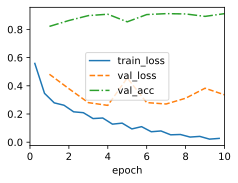

In [10]:
model = ResNet18(lr=0.01)
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128, resize=(96, 96))
model.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
trainer.fit(model, data)

## ResNeXt

One of the challenges one encounters in the design of ResNet is the trade-off between nonlinearity and dimensionality within a given block. That is, we could add more nonlinearity by increasing the number of layers, or by increasing the width of the convolutions. An alternative strategy is to increase the number of channels that can carry information between blocks. Unfortunately, the latter comes with a quadratic penalty since the computational cost of ingesting $c_\textrm{i}$ channels and emitting $c_\textrm{o}$ channels is proportional to $\mathcal{O}(c_\textrm{i} \cdot c_\textrm{o})$ (see our discussion in that section). 

We can take some inspiration from the Inception block of the figure which has information flowing through the block in separate groups. Applying the idea of multiple independent groups to the ResNet block of the figure led to the design of ResNeXt [@Xie.Girshick.Dollar.ea.2017].
Different from the smorgasbord of transformations in Inception, 
ResNeXt adopts the *same* transformation in all branches,
thus minimizing the need for manual tuning of each branch. 

![The ResNeXt block: a grouped $3 \times 3$ convolution with $\mathit{g}$ groups, sandwiched between two $1 \times 1$ convolutions that mix information across groups. Grouped convolution uses $\mathit{g}$ times fewer multiply-adds than a dense convolution; the block is a bottleneck residual block when the number of intermediate channels $\mathit{b}$ is less than $\mathit{c}$.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/arch-resnext-block.svg)

Breaking up a convolution from $c_\textrm{i}$ to $c_\textrm{o}$ channels into one of $g$ groups of size $c_\textrm{i}/g$ generating $g$ outputs of size $c_\textrm{o}/g$ is called, quite fittingly, a *grouped convolution*. The arithmetic cost is reduced from $\mathcal{O}(c_\textrm{i} \cdot c_\textrm{o})$ to $\mathcal{O}(g \cdot (c_\textrm{i}/g) \cdot (c_\textrm{o}/g)) = \mathcal{O}(c_\textrm{i} \cdot c_\textrm{o} / g)$, i.e., it uses $g$ times fewer multiply-adds. The number of parameters is likewise reduced from a $c_\textrm{i} \times c_\textrm{o}$ matrix to $g$ smaller matrices of size $(c_\textrm{i}/g) \times (c_\textrm{o}/g)$. Wall-clock speedup depends on kernel efficiency and memory traffic and can be much smaller. In what follows we assume that both $c_\textrm{i}$ and $c_\textrm{o}$ are divisible by $g$.

The only challenge in this design is that no information is exchanged between the $g$ groups. The ResNeXt block of 
the figure amends this in two ways: the grouped convolution with a $3 \times 3$ kernel is sandwiched in between two $1 \times 1$ convolutions. The second one serves double duty in changing the number of channels back. The benefit is that we only pay the $\mathcal{O}(c \cdot b)$ cost for $1 \times 1$ kernels and can make do with an $\mathcal{O}(b^2 / g)$ cost for $3 \times 3$ kernels. Similar to the residual block implementation in
that section, the residual connection is replaced (thus generalized) by a $1 \times 1$ convolution.

The block in the figure will also play a major role in the design of generic modern CNNs in that section. Grouped convolutions appeared in AlexNet [@Krizhevsky.Sutskever.Hinton.2012], where most channels were split into two groups so that each GPU could process one group with limited cross-GPU communication.

The following implementation of the `ResNeXtBlock` class takes as argument `groups` ($g$), with 
`bot_channels` ($b$) intermediate (bottleneck) channels. Lastly, when we need to reduce the height and width of the representation, we add a stride of $2$ by setting `use_1x1conv=True, strides=2`.

In [11]:
class ResNeXtBlock(nn.Module):
    """The ResNeXt block."""
    def __init__(self, num_channels, groups, bot_mul, use_1x1conv=False,
                 strides=1):
        super().__init__()
        bot_channels = int(round(num_channels * bot_mul))
        self.conv1 = nn.LazyConv2d(bot_channels, kernel_size=1, stride=1)
        self.conv2 = nn.LazyConv2d(bot_channels, kernel_size=3,
                                   stride=strides, padding=1,
                                   groups=groups)
        self.conv3 = nn.LazyConv2d(num_channels, kernel_size=1, stride=1)
        self.bn1 = nn.LazyBatchNorm2d()
        self.bn2 = nn.LazyBatchNorm2d()
        self.bn3 = nn.LazyBatchNorm2d()
        if use_1x1conv:
            self.conv4 = nn.LazyConv2d(num_channels, kernel_size=1, 
                                       stride=strides)
            self.bn4 = nn.LazyBatchNorm2d()
        else:
            self.conv4 = None

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = F.relu(self.bn2(self.conv2(Y)))
        Y = self.bn3(self.conv3(Y))
        if self.conv4:
            X = self.bn4(self.conv4(X))
        return F.relu(Y + X)

Its use is entirely analogous to that of the `ResNetBlock` discussed previously. For instance, when using (`use_1x1conv=False, strides=1`), the input and output are of the same shape. Alternatively, setting `use_1x1conv=True, strides=2` halves the output height and width.

In [12]:
blk = ResNeXtBlock(32, 16, 1)
X = d2l.randn(4, 32, 96, 96)
blk(X).shape

torch.Size([4, 32, 96, 96])

## Concatenation instead of Addition: DenseNet

The residual block computes $f(\mathbf{x}) = \mathbf{x} + g(\mathbf{x})$, splitting a function into the identity plus a correction, much as a Taylor expansion splits a function into a leading term plus higher-order refinements. What if we want to keep more than two terms, without forcing them to share a sum? *DenseNet* (dense convolutional network) [@Huang.Liu.Van-Der-Maaten.ea.2017] answers by *concatenating* a layer's output onto its input along the channel dimension, so every layer receives the feature maps of all layers that precede it. Applying an increasingly complex sequence of functions thus maps $\mathbf{x}$ to

$$
\mathbf{x} \to \left[
\mathbf{x},
f_1(\mathbf{x}),
f_2\left(\left[\mathbf{x}, f_1\left(\mathbf{x}\right)\right]\right), f_3\left(\left[\mathbf{x}, f_1\left(\mathbf{x}\right), f_2\left(\left[\mathbf{x}, f_1\left(\mathbf{x}\right)\right]\right)\right]\right), \ldots\right],
$$

where $[\cdot, \cdot]$ denotes concatenation. The name reflects the resulting dependency graph: the last layer of such a chain is densely connected to all its predecessors. the figure contrasts the two designs.

![A residual block (left) adds its input back to the output, keeping the number of channels fixed. A DenseNet block (right) concatenates each convolution's output onto its input, so the number of channels grows with every layer while all earlier features remain directly accessible.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/arch-densenet-block.svg)

A DenseNet consists of *dense blocks*, which define how outputs are concatenated, alternating with *transition layers*, which shrink the accumulated channels back down. Each convolution inside a dense block uses the "batch normalization, activation, and convolution" pre-activation ordering explored in the exercises below.

In [13]:
def conv_block(num_channels):
    return nn.Sequential(
        nn.LazyBatchNorm2d(), nn.ReLU(),
        nn.LazyConv2d(num_channels, kernel_size=3, padding=1))

A *dense block* consists of multiple convolution blocks, each using the same number of output channels. In the forward propagation, however, we concatenate the input and output of each convolution block on the channel dimension. Lazy evaluation allows us to adjust the dimensionality automatically.

In [14]:
class DenseBlock(nn.Module):
    def __init__(self, num_convs, num_channels):
        super(DenseBlock, self).__init__()
        layer = []
        for i in range(num_convs):
            layer.append(conv_block(num_channels))
        self.net = nn.Sequential(*layer)

    def forward(self, X):
        for blk in self.net:
            Y = blk(X)
            # Concatenate input and output of each block along the channels
            X = torch.cat((X, Y), dim=1)
        return X

In the following example,
we define a `DenseBlock` instance with two convolution blocks of 10 output channels.
When using an input with three channels, we will get an output with  $3 + 10 + 10=23$ channels. The number of convolution block channels controls the growth in the number of output channels relative to the number of input channels. This is also referred to as the *growth rate*.

In [15]:
blk = DenseBlock(2, 10)
X = torch.randn(4, 3, 8, 8)
Y = blk(X)
Y.shape

torch.Size([4, 23, 8, 8])

Since each dense block increases the number of channels, stacking many of them without correction would produce an excessively wide model. A *transition layer* reduces the number of channels by a $1\times 1$ convolution and halves the height and width via average pooling with a stride of 2.

In [16]:
def transition_block(num_channels):
    return nn.Sequential(
        nn.LazyBatchNorm2d(), nn.ReLU(),
        nn.LazyConv2d(num_channels, kernel_size=1),
        nn.AvgPool2d(kernel_size=2, stride=2))

Apply a transition layer with 10 channels to the output of the dense block in the previous example.  This reduces the number of output channels to 10, and halves the height and width.

In [17]:
blk = transition_block(10)
blk(Y).shape

torch.Size([4, 10, 4, 4])

A full DenseNet alternates four dense blocks with transition layers, mirroring
the four-stage layout of ResNet-18; assembling and training one is a
straightforward variation on the ResNet code above. Feature reuse makes
DenseNet parameter-efficient: it reached ResNet-level ImageNet accuracy with
fewer parameters. Concatenation carries a cost that addition does not. The
unique feature maps grow linearly with depth, but a naive implementation
repeatedly materializes ever-wider concatenations and temporary normalized
outputs, producing quadratic memory growth inside a dense block.
Memory-efficient implementations recompute those temporaries during
backpropagation [@pleiss2017memory]. The remaining activation traffic
helped residual addition become the more common choice at scale.

## Summary and Discussion

Nested function classes are desirable because adding capacity then preserves
the functions already available. A residual branch parametrizes a block as the
identity plus a correction. In a pre-activation block, setting that correction
to zero gives the identity exactly; in the post-activation block used above,
the statement holds on the nonnegative inputs produced by the preceding ReLU.


The residual mapping makes a near-identity transformation accessible by
driving the correction toward zero, while the shortcut supplies a direct path
for activations and gradients. This enabled the original ResNet experiments
to train networks as deep as 152 layers [@He.Zhang.Ren.ea.2016].
Residual branches can also be initialized near the identity, for example by
zero-initializing the final normalization scale. Ordinary randomly initialized
residual blocks are not exact identities, and inserting new blocks during
training requires a separate function-preserving procedure.

Prior to residual connections,
bypassing paths with gating units were introduced
to effectively train highway networks with over 100 layers
[@srivastava2015highway].
Using identity functions as bypassing paths,
ResNet performed well
on multiple computer vision tasks.
Residual connections had a major influence on the design of subsequent deep neural networks, of either convolutional or sequential nature.
As we will introduce later,
the Transformer architecture [@Vaswani.Shazeer.Parmar.ea.2017]
adopts residual connections (together with other design choices) and is pervasive
in areas as diverse as
language, vision, speech, and reinforcement learning.
Every transformer block in a large language model, and every block of the
denoising networks behind diffusion models, is a residual block. By parameter
count, most residual blocks in the world now live outside convolutional
networks.

ResNeXt illustrates the trade between arithmetic and activation width. A
grouped convolution is a block-diagonal channel-mixing matrix, reducing
multiply-adds while retaining a wide representation. ShiftNet
[@wu2018shift] takes this idea further by replacing spatial
multiplications with shifts of channel activations. The shifts use no
floating-point multiply-adds, though moving the activation data still incurs
memory traffic.

A common feature of the designs we have discussed so far is that the network design is fairly manual, primarily relying on the ingenuity of the designer to find the "right" network hyperparameters. While clearly feasible, it is also very costly in terms of human time and there is no guarantee that the outcome is optimal in any sense. In that section we will discuss a number of strategies for obtaining high quality networks in a more automated fashion. In particular, we will review the notion of *network design spaces* that led to the RegNetX/Y models
[@Radosavovic.Kosaraju.Girshick.ea.2020].

## Exercises

1. What are the major differences between the Inception block in the figure and the residual block? How do they compare in terms of computation, accuracy, and the classes of functions they can describe?
1. Refer to Table 1 in the ResNet paper [@He.Zhang.Ren.ea.2016] to implement different variants of the network. 
1. For deeper networks, ResNet introduces a "bottleneck" architecture to reduce model complexity. Try to implement it.
1. In subsequent versions of ResNet, the authors changed the "convolution, batch normalization, and activation" structure to the "batch normalization, activation, and convolution" structure. Make this improvement yourself. See Figure 1 in @He.Zhang.Ren.ea.2016*1 for details. This ordering is essentially what ConvNeXt adopts (that section).
1. Why can't we just increase the complexity of functions without bound, even if the function classes are nested?
1. One of the advantages claimed in the DenseNet paper [@Huang.Liu.Van-Der-Maaten.ea.2017] is that its models have fewer parameters than comparable ResNets. Why is this the case? Consider which computations a concatenated feature saves relative to recomputing it.
1. For a dense block whose $k$ convolutions each emit $g$ channels (the growth rate) on an input with $c$ channels, how many channels does the $i$-th convolution consume? Sum these to compare the activation memory of the dense block with that of $k$ residual blocks of constant width $c$, and relate your answer to the memory-efficient implementations of @pleiss2017memory.

[Discussions](https://d2l.discourse.group/t/86)